# Annotation listing and navigation

This notebook imports pUC19 from a GenBank file, loads its feature annotations,
and navigates to the MCS (multiple cloning site) using `widget.go_to()` and
`widget.show()`.

In [1]:
import os
import tempfile
import gen

## Import pUC19

Create a fresh in-memory repository, import a GenBank file and start a new plot figure (or widget in Jupyter terms).

In [10]:
# Adjust this path if running from outside the project root.
FIXTURE = os.path.abspath("../../fixtures/puc19.gb")

tmp = tempfile.mkdtemp()
repo = gen.Repository(os.path.join(tmp, ".gen"))
repo.import_genbank(FIXTURE)

bg = repo.get_block_groups()[0]
print("Block group:", bg.name)

fig = bg.plot(rows=24)

Block group: sequence-222046-


## Annotations
Annotation groups associated with the sequence or its ancestors are automatically loaded as an annotation track titled "Stored annotations"

Additional GFF3 or BED annotation files can be loaded at any time:

```python
fig.add_annotation_track(file="path/to/features.gff3")
```

To start with a blank canvas before loading your own files, clear the auto-loaded tracks:

```python
fig.clear_all_annotations()
```

## List all annotations

`fig.list_annotations()` returns `Annotation` objects spanning all
sources (track panels and inline highlights).  Each annotation exposes `.name`,
`.locus`, and can be passed directly to `fig.go_to()` or `fig.show()`.

In [11]:
anns = fig.list_annotations()
print(f"{len(anns)} annotations loaded")
for a in anns:
    print(a)

21 annotations loaded
Annotation(name="source", segments=1)
Annotation(name="pBR322ori-F", segments=1)
Annotation(name="L4440", segments=1)
Annotation(name="CAP binding site", segments=1)
Annotation(name="lac promoter", segments=3)
Annotation(name="lac operator", segments=1)
Annotation(name="M13/pUC Reverse", segments=1)
Annotation(name="M13 rev", segments=1)
Annotation(name="M13 Reverse", segments=1)
Annotation(name="lacZ-alpha", segments=1)
Annotation(name="MCS", segments=1)
Annotation(name="M13 Forward", segments=1)
Annotation(name="M13 fwd", segments=1)
Annotation(name="M13/pUC Forward", segments=1)
Annotation(name="pRS-marker", segments=1)
Annotation(name="pGEX 3'", segments=1)
Annotation(name="pBRforEco", segments=1)
Annotation(name="AmpR promoter", segments=1)
Annotation(name="AmpR", segments=2)
Annotation(name="Amp-R", segments=1)
Annotation(name="ori", segments=2)


## Navigate to the MCS

Filter for the MCS feature and navigate to it two ways:

* `widget.go_to(ann)` — left-pins the annotation start at column 12, no highlight
* `widget.show(ann)` — left-pins the annotation start and adds a highlight

In [12]:
mcs = next(a for a in anns if a.name == "MCS")
print("MCS locus:", mcs.locus)
print("MCS start:", mcs.locus.start())

MCS locus: [348d9388:0-2686:631-688]
MCS start: GraphPos(348d9388[0..2686] +631)



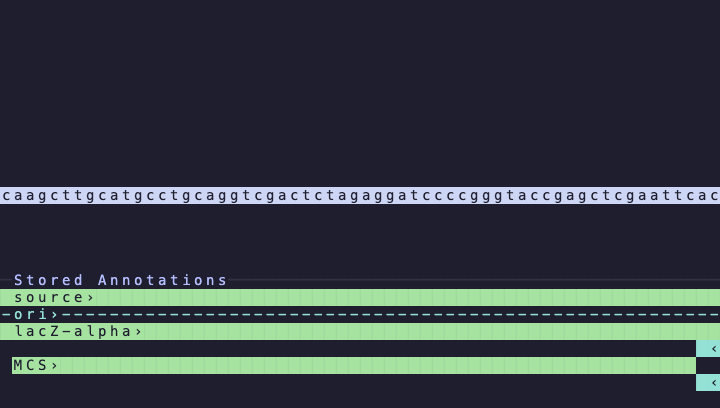

In [15]:
# Left-pin the MCS start at column 12 from the left edge.
fig.go_to(mcs)
fig


In [16]:
# Freeze the cell so we can compare
fig.freeze()
fig = bg.plot(rows=24)

In [17]:
# Also add a highlight.
fig.show(mcs)
fig

## Search, filter, and navigate

Search for a sequence, wrap matches as `Annotation` objects, then navigate to one.

In [33]:
fig.freeze()
fig = bg.plot(rows=24)

# Search for Dcm methylation sites and add matches to the widget.
results = bg.search("CCWGG")

# The search query is a palindrome, so every match will also be a match on the opposite strand,
# filter by strand to prevent double labels:
matches = [locus for locus in results if locus.strand=='forward']
print(f"{len(matches)} match(es) found")

for i, locus in enumerate(matches):
    fig.add_annotation(gen.Annotation(locus, f"Dcm ({i + 1} of {len(matches)})"), )

5 match(es) found


In [36]:
# List all annotations now in the widget, then navigate to the first hit.
anns2 = fig.list_annotations()
print(f"{len(anns2)} total annotations")

hits = [a for a in anns2 if a.name.startswith("Dcm")]
print(f"{len(hits)} Dcm hit(s)")


#fig.go_to(hits[0])
fig

26 total annotations
5 Dcm hit(s)


In [ ]:
results